# Download dataset

In [21]:
import os
import kagglehub
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define download path
os.environ["KAGGLEHUB_CACHE"] = "../datasets"

# Download dataset
path = kagglehub.dataset_download("adilshamim8/social-media-addiction-vs-relationships")
csv_file = os.path.join(path, "Students Social Media Addiction.csv")
df = pd.read_csv(csv_file)
print('\ndataset downloaded at ', path)
print('reading file...')


dataset downloaded at  ../datasets\datasets\adilshamim8\social-media-addiction-vs-relationships\versions\3
reading file...


# General dataset exploration

In [22]:
print('*'*30)
print('GENERAL DATASET INFORMATION')
print('*'*30)

print('Columns and records count:')
df.info()
df.describe()
print('*'*30)

print('Gender distribution:')
print(df['Gender'].value_counts())
print('*'*30)

print('Age calculations:')
print(f"mean:\t {df['Age'].mean():.1f}")
print('median:\t', df['Age'].median())
print('*'*30)

print('Countries data:')
print('unique count:\t', df['Country'].nunique()) # len(df['Country'].unique())

******************************
GENERAL DATASET INFORMATION
******************************
Columns and records count:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Confli

# Univariate analysis

This section investigates the distribution of individual variables within the dataset.
The following features were selected for inspection:
- Avg_Daily_Usage_Hours
- Sleep_Hours_Per_Night
- Age

## Methodology

Univariate analysis, graphs are plotted based on one feature at a time, in order to understand its distribution over the dataset. Histograms and boxplots are used to visualize characteristics such as central tendency, dispersion, outliers, noise and errors in the dataset.

Understanding the distribution of features is important because it can determine if the data approximates a normal distribution. Additionally, identifying distribution patterns provides useful context for later correlation analysis.

Distribution of the Avg_Daily_Usage_Hours column


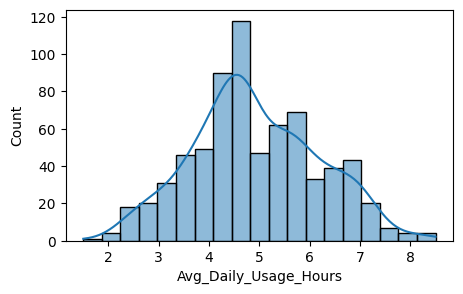

In [37]:
print('Distribution of the Avg_Daily_Usage_Hours column')
plt.figure(figsize=(5, 3))
sns.histplot(
    data=df, 
    x='Avg_Daily_Usage_Hours', 
    kde=True, 
    bins='auto'
)
plt.show()

This plot depicts a histogram highlighting the distribution of the Avg_Daily_Usage_Hours feature.
These results shows an almost ideal normal distribution which can be defined as:
A continuous, symmetric, bell-shaped probability distribution where most data points cluster around a central mean,with frequencies tapering off symmetrically toward the tails.


Distribution of the Sleep_Hours_Per_Night column


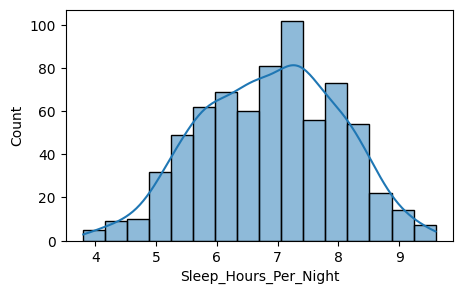

In [39]:
print('Distribution of the Sleep_Hours_Per_Night column')
plt.figure(figsize=(5, 3))
sns.histplot(
    data=df, 
    x='Sleep_Hours_Per_Night', 
    kde=True, 
    bins='auto'
)
plt.show()

Similarly, this plot depicts a histogram highlighting the distribution of the Sleep_Hours_Per_Night feature.
The distribution of the values are almost identical to an ideal normal distribution plot.

Distribution of the Age column


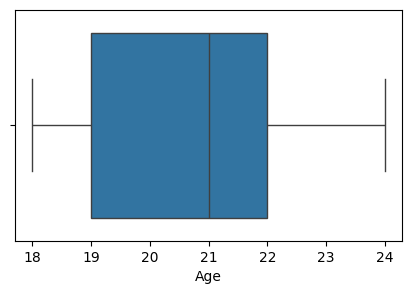

In [43]:
print('Distribution of the Age column')
plt.figure(figsize=(5, 3))
sns.boxplot(data=df, x='Age')
plt.show()

The boxplot suggests a relatively symmetric distribution with no evident outliers, though the exact distribution shape cannot be inferred solely from this visualization.

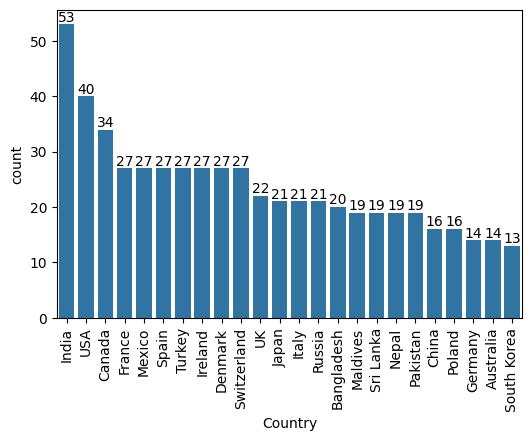

Countries that has ten or more records:  24
Which is: 21.8% of the 110 countries present.


In [61]:

n = 10
top_n = df['Country'].value_counts()[df['Country'].value_counts() > n].index #more than 10 records for simplicity
plt.figure(figsize=(6, 4))
ax = sns.countplot(
    data=df, 
    x='Country',
    order=top_n
)
ax.bar_label(ax.containers[0])
plt.xticks(rotation=90)
plt.show()
print('Countries that has ten or more records: ', len(df['Country'].value_counts()[df['Country'].value_counts() > n].index))
print(f"Which is: {(len(df['Country'].value_counts()[df['Country'].value_counts() > n].index) / df['Country'].nunique()) * 100:.1f}% of the 110 countries present.")

# Bivariate Analysis

Gender
Female    353
Male      352
Name: count, dtype: int64


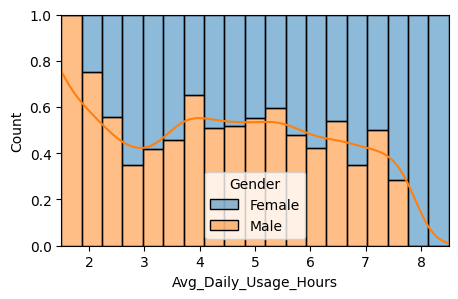

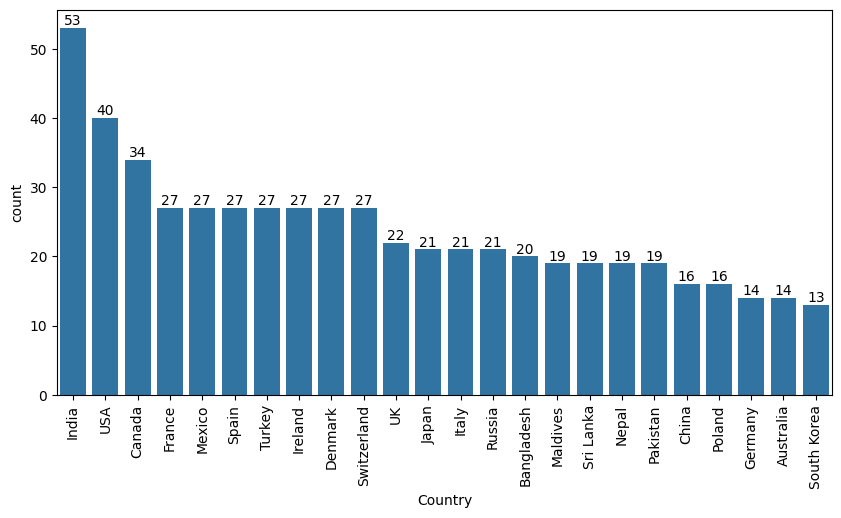

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# df.hist(edgecolor='black', linewidth=1, figsize=(12, 8))
# plt.show()
print(df['Gender'].value_counts())
plt.figure(figsize=(5, 3))
sns.histplot(
    data=df, 
    x='Avg_Daily_Usage_Hours', 
    kde=True, 
    color='skyblue',
    hue='Gender',
    multiple='fill'
)
plt.show()

n = 10
top_n = df['Country'].value_counts()[df['Country'].value_counts() > n].index #more than 10 records for simplicity
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=df, 
    x='Country',
    order=top_n
)
ax.bar_label(ax.containers[0])
plt.xticks(rotation=90)
plt.show()

Gender
Female    353
Male      352
Name: count, dtype: int64


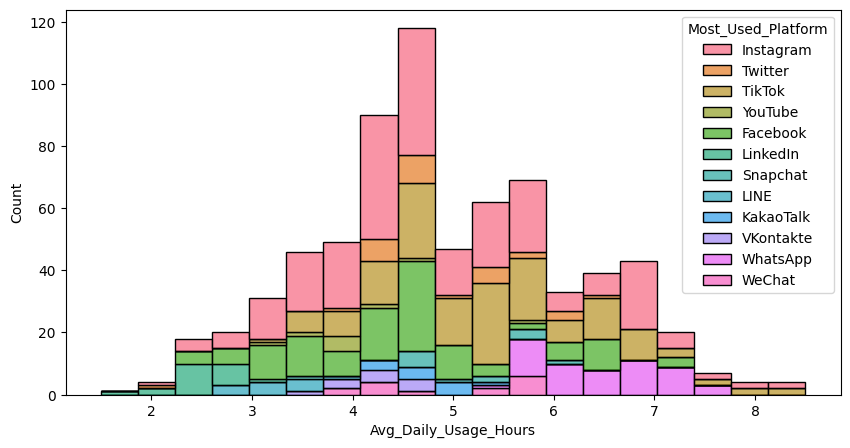

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# df.hist(edgecolor='black', linewidth=1, figsize=(12, 8))
# plt.show()
print(df['Gender'].value_counts())
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df, 
    x='Avg_Daily_Usage_Hours', 
    color='skyblue',
    hue="Most_Used_Platform",
    multiple="stack"
)
plt.show()